# Class Notes: Boosting and Ensembles (23 June 2026)

This session is the deep dive into boosting, following on from the ensemble intro at the end of the 19 June decision tree notes.

Topics covered:
1. Recap: why ensembles
2. Bagging vs boosting (the two families)
3. Boosting: the core idea
4. The weak learner: why a shallow tree, with pros and cons
5. AdaBoost (Adaptive Boosting)
6. Gradient Boosting
7. XGBoost
8. Comparing them in practice

---

In [1]:

# Setup for this notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


## 1. Recap: Why Ensembles

A single decision tree is easy to read but unstable: a small change in the data can reshape the whole tree, and a deep tree overfits. That was the main weakness we ended the decision tree notes on.

**An ensemble combines many models so the group prediction is stronger and steadier than any single model.**

Plainly: instead of trusting one tree, we build a crowd of them and let the crowd decide, which cancels out the mistakes of any single member.

The two ways to build that crowd are bagging and boosting.

---

## 2. Bagging vs Boosting

Both combine many trees, but they differ in how the trees are built and what error they attack.

| Aspect | Bagging (e.g. Random Forest) | Boosting (AdaBoost, GBM, XGBoost) |
|---|---|---|
| How trees are built | in parallel, independently | in sequence, each fixing the last |
| Training data per tree | a random bootstrap sample | the full data, reweighted or refit to errors |
| Trees are | deep and strong, then averaged | shallow and weak, then added up |
| Mainly reduces | variance (overfitting) | bias (underfitting) |
| Risk | less prone to overfit | can overfit if pushed too hard |

Plainly: bagging builds many strong trees separately and averages them to calm the variance, boosting builds many weak trees one after another where each cleans up the previous one's mistakes to cut the bias. The rest of these notes are about the boosting side.

```
Bagging (parallel):              Boosting (sequential):
  data -> [tree1] \                [tree1] -> errors -> [tree2] -> errors -> [tree3]
  data -> [tree2]  > vote           (each tree corrects the one before it)
  data -> [tree3] /
```

---

## 3. Boosting: the Core Idea

**Boosting trains weak learners one at a time, where each new learner focuses on the rows the previous ones got wrong, then combines them into a single weighted prediction.**

Plainly: start with a weak model, see where it fails, build the next weak model to fix those failures, and repeat, so the team gets stronger with every round.

The key mindset shift from bagging: the trees are not independent. Each one is deliberately built to patch the current team's weak spots. That is what steadily drives down bias and turns a pile of barely useful stumps into one accurate model.

---

## 4. The Weak Learner: Why a Shallow Tree

Boosting needs a base model to repeat, and that base model is deliberately weak.

**A weak learner is a model that only needs to do slightly better than random guessing, and a shallow decision tree (often a stump of depth 1) is the standard choice.**

Plainly: boosting does not want a strong model at each step, it wants a simple one it can correct and stack many times, and a short tree is exactly that.

Pros of using a tree as the weak learner:
- Handles numeric and categorical features with no scaling needed.
- A shallow tree is fast to train, and boosting trains a lot of them.
- Trees naturally capture simple splits that the sequence then builds into a strong combined model.

Cons:
- A single shallow tree has high bias on its own, which is exactly why one alone is weak.
- Because boosting keeps chasing earlier mistakes, it can start fitting noise if you add too many trees or set the learning rate too high, so the number of trees and the learning rate both need tuning.

---

## 5. AdaBoost (Adaptive Boosting)

AdaBoost is the original boosting algorithm, and it works by reweighting the rows.

**AdaBoost gives every training row a weight, and after each weak tree it raises the weight of the rows that were misclassified so the next tree is forced to focus on them. Each tree also earns a say (alpha) based on how accurate it was.**

Plainly: the rows the current team keeps getting wrong get louder and louder until a later tree finally handles them, and the more accurate a tree is, the bigger its vote in the final answer.

### The steps

```
1. Start every row with equal weight (1/n).
2. Train a weak tree on the weighted data.
3. Compute its error (weighted fraction misclassified).
4. Compute its say:  alpha = 0.5 * ln((1 - error) / error).
5. Raise the weight of misclassified rows, lower the weight of correct ones, renormalize.
6. Repeat for the next tree.
7. Final prediction = weighted vote of all trees, using each tree's alpha.
```

Worked example. Ten rows each start with weight 0.1, and a stump misclassifies 3 of them, so its error is 0.30:

```
alpha = 0.5 * ln((1 - 0.30) / 0.30) = 0.4236

reweight, then renormalize so the weights sum to 1:
  misclassified rows: 0.1 -> 0.1667 each   (heavier, next tree focuses here)
  correct rows:       0.1 -> 0.0714 each   (lighter)
  check: 3(0.1667) + 7(0.0714) = 1.0000
```

(Verified in Python.) Notice the misclassified rows now carry more than twice the weight of the correct ones, and a low error tree gets a high alpha, so accurate trees dominate the final vote.

---

In [2]:
# AdaBoost weight update on 10 rows where a stump misclassifies 3
err = 0.30
alpha = 0.5 * np.log((1 - err) / err)
w0 = 1 / 10
w_wrong, w_right = w0 * np.exp(alpha), w0 * np.exp(-alpha)
Z = 3 * w_wrong + 7 * w_right      # normalizer so weights sum to 1
print(f"error = {err}  ->  alpha (this tree's say) = {alpha:.4f}")
print(f"misclassified row weight: {w0:.3f} -> {w_wrong / Z:.4f}  (heavier)")
print(f"correct row weight      : {w0:.3f} -> {w_right / Z:.4f}  (lighter)")
print(f"check total weight = {(3 * w_wrong + 7 * w_right) / Z:.4f}")

error = 0.3  ->  alpha (this tree's say) = 0.4236
misclassified row weight: 0.100 -> 0.1667  (heavier)
correct row weight      : 0.100 -> 0.0714  (lighter)
check total weight = 1.0000


## 6. Gradient Boosting

Gradient boosting keeps the sequential idea but changes what each new tree learns.

**Gradient boosting fits each new tree to the residuals (the leftover errors) of the current ensemble, nudging the overall prediction in the direction that lowers the loss.**

Plainly: instead of reweighting rows like AdaBoost, it looks at how far off the current prediction is for each row and trains the next tree to predict that gap, then adds a scaled version of it on top.

```
prediction after each round:
  F0 = a simple starting guess (like the mean)
  residual = actual - F0
  F1 = F0 + (learning_rate * tree fit to the residual)
  residual = actual - F1
  F2 = F1 + (learning_rate * tree fit to the new residual)
  ... repeat
```

The **learning rate** scales how big each nudge is. A small learning rate (say 0.1) takes cautious steps and usually generalizes better, but needs more trees. Gradient boosting is more flexible than AdaBoost and works cleanly for both regression and classification, which is why it is the more common modern choice.

---

## 7. XGBoost

**XGBoost (Extreme Gradient Boosting) is an optimized, regularized implementation of gradient boosting.**

Plainly: it is the same residual fitting idea, engineered to be faster and less prone to overfitting.

What it adds on top of plain gradient boosting:
- An L1 and L2 penalty on the trees, so it regularizes the way Ridge and LASSO did for linear regression, which fights overfitting.
- Built in handling of missing values.
- Speed engineering (parallelized tree construction, cache awareness), so it trains quickly on large tabular data.

This combination is why XGBoost wins a large share of tabular data competitions and is worth knowing by name.

---

## 8. Comparing Them in Practice

The order of accuracy on real tabular data is usually: a single decision tree at the bottom, then bagging (Random Forest) and boosting (AdaBoost, Gradient Boosting, XGBoost) clearly above it, with the boosting methods often edging out bagging when they are tuned well.

The tradeoff to remember: bagging is easier to tune and hard to overfit, boosting can reach higher accuracy but needs its number of trees and learning rate set carefully, otherwise it starts memorizing noise. The accompanying code fits all four on the same dataset so the gap over a single tree is visible in the numbers.

5-fold mean accuracy:
  single decision tree       0.9174


  random forest (bagging)    0.9631


  AdaBoost (boosting)        0.9772


  gradient boosting          0.9631


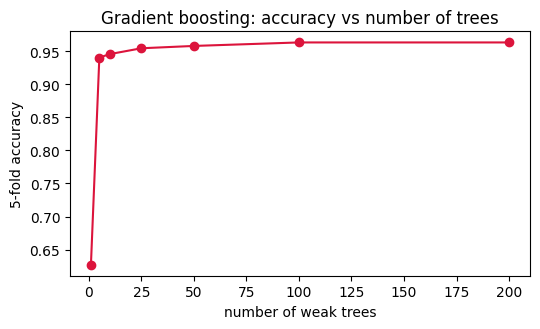

In [3]:
# single tree vs bagging vs the boosting family on the same dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)

X, y = load_breast_cancer(return_X_y=True)
models = {
    "single decision tree":     DecisionTreeClassifier(random_state=0),
    "random forest (bagging)":  RandomForestClassifier(n_estimators=100, random_state=0),
    "AdaBoost (boosting)":      AdaBoostClassifier(n_estimators=100, random_state=0),
    "gradient boosting":        GradientBoostingClassifier(random_state=0),
}
print("5-fold mean accuracy:")
for name, m in models.items():
    print(f"  {name:26} {cross_val_score(m, X, y, cv=5).mean():.4f}")

# how boosting accuracy climbs as more weak trees are added
counts = [1, 5, 10, 25, 50, 100, 200]
accs = [cross_val_score(GradientBoostingClassifier(n_estimators=n, random_state=0),
                        X, y, cv=5).mean() for n in counts]
plt.figure(figsize=(5.5, 3.4))
plt.plot(counts, accs, "o-", color="crimson")
plt.xlabel("number of weak trees"); plt.ylabel("5-fold accuracy")
plt.title("Gradient boosting: accuracy vs number of trees")
plt.tight_layout(); plt.show()